In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import seaborn as sns
import milopy
import milopy.core as milo
import matplotlib.pyplot as plt
import milopy.plot as milopl

In [2]:
adata = sc.read_h5ad('/home/jupyter/data/ge_korea/results/ge_korea_final_annot.h5ad')

In [3]:
adata_t = sc.read_h5ad('/home/jupyter/data/ge_korea/results/tcr_analysis/mvtcr_adata_new_correct_progression.h5ad')
adata_t.obs['progression'] = adata_t.obs['patient'].map({
 'E30': 'Fast',
 'E26': 'Slow',
 'E15': 'Slow',
 'E21': 'Slow',
 'E43': 'Fast',
 'E37': 'Slow',
 'E14': 'Fast',
 'E44': 'Fast',
 'E36': 'Slow',
 'E42': 'Slow',
 'E31': 'Fast',
 'E17': 'Slow',
 'E38': 'Slow',
 'E16': 'Fast',
 'E24': 'Slow',
 'E22': 'Fast',
 'E45': 'Fast',
 'E35': 'Slow',
 'E33': 'Slow',
 'E27': 'Fast',
 'E23': 'Slow',
 'E34': 'Fast',
 'E39': 'Slow',
 'E25': 'Fast',
 'E41': 'Slow',
 'E12': 'Fast',
 'E18': 'Slow',
 'E20': 'Slow',
 'E32': 'Fast',
 'E46': 'Fast',
 'E40': 'Slow',
 'E29': 'Slow',
 'E19': 'Fast'})

In [4]:
adata = adata[~adata.obs['normal'].isin(['AN','DN'])]

In [5]:
temp = adata_t.obs[['sample_x','progression']].drop_duplicates()
temp.index = temp['sample_x']
progression_dict = temp['progression'].to_dict()

In [6]:
adata.obs['progression'] = adata.obs['patient'].map(
    progression_dict)

/tmp/ipykernel_4707/1323683419.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['progression'] = adata.obs['patient'].map(


# All cells

In [7]:
all_counts = adata.obs[['annot_final','sample']].value_counts().reset_index().pivot(
    columns='annot_final',index='sample',values=0).fillna(0)
all_props = all_counts.div(all_counts.sum(axis=1),axis=0)
all_props['Progression'] = all_props.index.map(progression_dict).astype(str)
all_props = all_props.sort_values('Progression')
all_props['Timepoint'] = [i.split('_')[1] for i in all_props.index]
all_props['Progression Timepoint'] = all_props['Progression'].astype(str) + ' ' + all_props['Timepoint'].astype(str)

In [8]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['mregDC'],
         all_props[all_props['Progression Timepoint'] == 'Slow B']['mregDC'])

RanksumsResult(statistic=-1.2292725943057183, pvalue=0.21896961893827893)

In [9]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['mregDC'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['mregDC'])

RanksumsResult(statistic=-0.9761870601839528, pvalue=0.32897177441062453)

In [10]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F2']['mregDC'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['mregDC'])

RanksumsResult(statistic=-1.0113681686514129, pvalue=0.31184025032995144)

In [11]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow B']['mregDC'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['mregDC'])

RanksumsResult(statistic=-0.06327719971683327, pvalue=0.9495457713618927)

In [12]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow F1']['mregDC'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['mregDC'])

RanksumsResult(statistic=0.8581278705797845, pvalue=0.3908218591695082)

In [13]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['mregDC'],
         all_props[all_props['Progression Timepoint'] == 'Fast F1']['mregDC'])

RanksumsResult(statistic=0.062217101683825514, pvalue=0.9503899436993509)

In [14]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['mregDC'],
         all_props[all_props['Progression Timepoint'] == 'Fast F2']['mregDC'])

RanksumsResult(statistic=1.323448205074589, pvalue=0.1856863700505329)

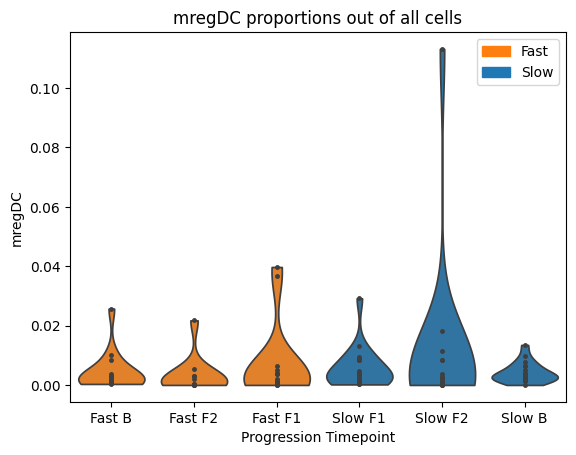

In [15]:
import matplotlib.patches as mpatches
sns.violinplot(data=all_props, y="mregDC", x="Progression Timepoint",
               hue="Progression Timepoint",inner="point",
              palette={'Slow B':'tab:blue','Slow F1':'tab:blue','Slow F2':'tab:blue',
                       'Fast B':'tab:orange','Fast F1':'tab:orange','Fast F2':'tab:orange'},cut=0
              )
orange_patch = mpatches.Patch(color='tab:orange',label='Fast')
blue_patch = mpatches.Patch(color='tab:blue', label='Slow')
plt.title('mregDC proportions out of all cells')
plt.legend(handles=[orange_patch,blue_patch],bbox_to_anchor=(1,1))
plt.savefig('/home/jupyter/data/ge_korea/results/apc_proportions/mregdc_div_all.pdf',
           bbox_inches='tight')

In [16]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['pDC'],
         all_props[all_props['Progression Timepoint'] == 'Slow B']['pDC'])

RanksumsResult(statistic=-1.0665747509417263, pvalue=0.2861639071174894)

In [17]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['pDC'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['pDC'])

RanksumsResult(statistic=0.8677218312746247, pvalue=0.385546631571102)

In [18]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F2']['pDC'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['pDC'])

RanksumsResult(statistic=-0.02352018996863751, pvalue=0.9812353336729821)

In [19]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow B']['pDC'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['pDC'])

RanksumsResult(statistic=1.297182594195082, pvalue=0.19456836815421574)

In [20]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow F1']['pDC'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['pDC'])

RanksumsResult(statistic=-0.03300491809922248, pvalue=0.973670665703503)

In [21]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['pDC'],
         all_props[all_props['Progression Timepoint'] == 'Fast F1']['pDC'])

RanksumsResult(statistic=-0.9954736269412082, pvalue=0.3195059648919748)

In [22]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['pDC'],
         all_props[all_props['Progression Timepoint'] == 'Fast F2']['pDC'])

RanksumsResult(statistic=0.9601486977992117, pvalue=0.3369803823558386)

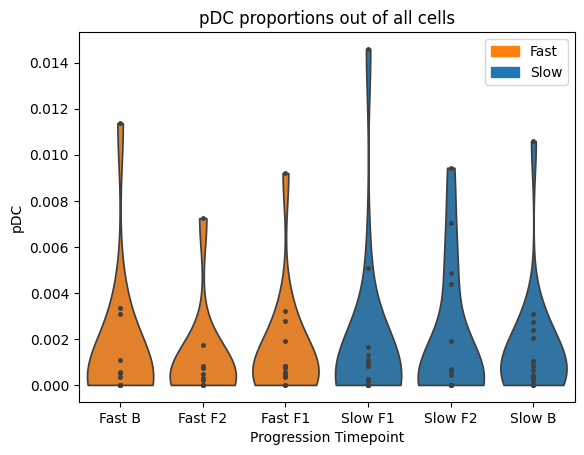

In [23]:
import matplotlib.patches as mpatches
sns.violinplot(data=all_props, y="pDC", x="Progression Timepoint",
               hue="Progression Timepoint",inner="point",
              palette={'Slow B':'tab:blue','Slow F1':'tab:blue','Slow F2':'tab:blue',
                       'Fast B':'tab:orange','Fast F1':'tab:orange','Fast F2':'tab:orange'},cut=0
              )
orange_patch = mpatches.Patch(color='tab:orange',label='Fast')
blue_patch = mpatches.Patch(color='tab:blue', label='Slow')
plt.title('pDC proportions out of all cells')
plt.legend(handles=[orange_patch,blue_patch],bbox_to_anchor=(1,1))
plt.savefig('/home/jupyter/data/ge_korea/results/apc_proportions/pdc_div_all.pdf',
           bbox_inches='tight')

In [24]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['cDC1'],
         all_props[all_props['Progression Timepoint'] == 'Slow B']['cDC1'])

RanksumsResult(statistic=-0.9038769075777341, pvalue=0.36606067525626174)

In [25]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['cDC1'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['cDC1'])

RanksumsResult(statistic=0.3073181485764296, pvalue=0.7586012230870767)

In [26]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F2']['cDC1'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['cDC1'])

RanksumsResult(statistic=-0.14112113981182506, pvalue=0.8877742436200267)

In [27]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow B']['cDC1'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['cDC1'])

RanksumsResult(statistic=1.0282544953985406, pvalue=0.3038301300878443)

In [28]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow F1']['cDC1'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['cDC1'])

RanksumsResult(statistic=-0.21453196764494611, pvalue=0.8301322406402155)

In [29]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['cDC1'],
         all_props[all_props['Progression Timepoint'] == 'Fast F1']['cDC1'])

RanksumsResult(statistic=-0.18665130505147656, pvalue=0.8519340379411375)

In [30]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['cDC1'],
         all_props[all_props['Progression Timepoint'] == 'Fast F2']['cDC1'])

RanksumsResult(statistic=0.259499648053841, pvalue=0.7952497535349383)

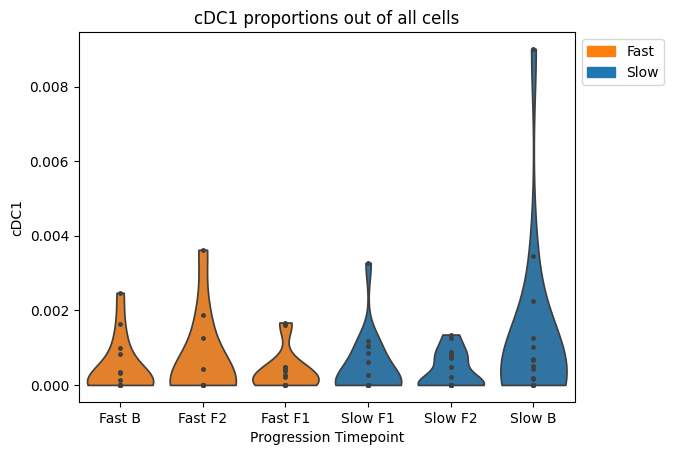

In [31]:
import matplotlib.patches as mpatches
sns.violinplot(data=all_props, y="cDC1", x="Progression Timepoint",
               hue="Progression Timepoint",inner="point",
              palette={'Slow B':'tab:blue','Slow F1':'tab:blue','Slow F2':'tab:blue',
                       'Fast B':'tab:orange','Fast F1':'tab:orange','Fast F2':'tab:orange'},cut=0
              )
orange_patch = mpatches.Patch(color='tab:orange',label='Fast')
blue_patch = mpatches.Patch(color='tab:blue', label='Slow')
plt.title('cDC1 proportions out of all cells')
plt.legend(handles=[orange_patch,blue_patch],bbox_to_anchor=(1,1))
plt.savefig('/home/jupyter/data/ge_korea/results/apc_proportions/cdc1_div_all.pdf',
           bbox_inches='tight')

In [32]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['cDC2'],
         all_props[all_props['Progression Timepoint'] == 'Slow B']['cDC2'])

RanksumsResult(statistic=-0.32539568672798425, pvalue=0.744881619545956)

In [33]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['cDC2'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['cDC2'])

RanksumsResult(statistic=0.32539568672798425, pvalue=0.744881619545956)

In [34]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F2']['cDC2'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['cDC2'])

RanksumsResult(statistic=-0.6820855090904878, pvalue=0.4951848829883486)

In [35]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow B']['cDC2'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['cDC2'])

RanksumsResult(statistic=-0.06327719971683327, pvalue=0.9495457713618927)

In [36]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow F1']['cDC2'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['cDC2'])

RanksumsResult(statistic=-0.4950737714883372, pvalue=0.6205480473200616)

In [37]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['cDC2'],
         all_props[all_props['Progression Timepoint'] == 'Fast F1']['cDC2'])

RanksumsResult(statistic=-0.8503003896789487, pvalue=0.39515809998581164)

In [38]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['cDC2'],
         all_props[all_props['Progression Timepoint'] == 'Fast F2']['cDC2'])

RanksumsResult(statistic=0.3892494720807615, pvalue=0.6970916100059634)

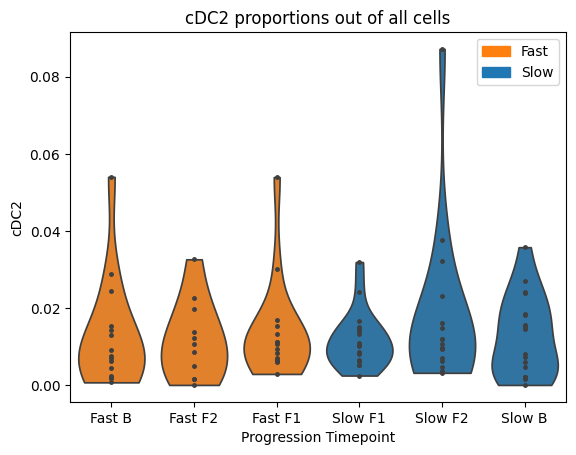

In [39]:
import matplotlib.patches as mpatches
sns.violinplot(data=all_props, y="cDC2", x="Progression Timepoint",
               hue="Progression Timepoint",inner="point",
              palette={'Slow B':'tab:blue','Slow F1':'tab:blue','Slow F2':'tab:blue',
                       'Fast B':'tab:orange','Fast F1':'tab:orange','Fast F2':'tab:orange'},cut=0
              )
orange_patch = mpatches.Patch(color='tab:orange',label='Fast')
blue_patch = mpatches.Patch(color='tab:blue', label='Slow')
plt.title('cDC2 proportions out of all cells')
plt.legend(handles=[orange_patch,blue_patch],bbox_to_anchor=(1,1))
plt.savefig('/home/jupyter/data/ge_korea/results/apc_proportions/cdc2_div_all.pdf',
           bbox_inches='tight')

In [40]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['B'],
         all_props[all_props['Progression Timepoint'] == 'Slow B']['B'])

RanksumsResult(statistic=-0.2711630722733202, pvalue=0.7862656133328394)

In [41]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['B'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['B'])

RanksumsResult(statistic=-2.27776980709589, pvalue=0.022740296115299704)

In [42]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F2']['B'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['B'])

RanksumsResult(statistic=-1.481771968024163, pvalue=0.13840098026316197)

In [43]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow B']['B'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['B'])

RanksumsResult(statistic=-2.135605490443123, pvalue=0.03271158352982045)

In [44]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow F1']['B'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['B'])

RanksumsResult(statistic=2.541378693640131, pvalue=0.011041625410374305)

In [45]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['B'],
         all_props[all_props['Progression Timepoint'] == 'Fast F1']['B'])

RanksumsResult(statistic=-0.020739033894608506, pvalue=0.9834538311633191)

In [46]:
from scipy.stats import ranksums
ranksums(all_props[(all_props['Progression Timepoint'] == 'Fast F1')]['B'],
         all_props[(all_props['Progression Timepoint'] == 'Fast F2')]['B'])

RanksumsResult(statistic=1.5829478531284302, pvalue=0.11343335048904161)

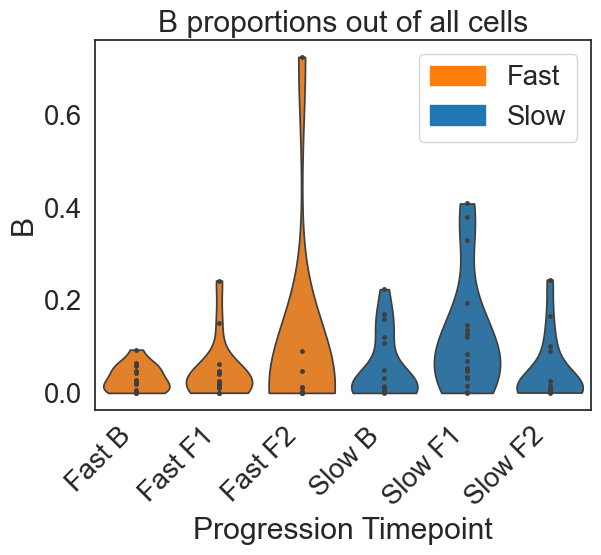

In [47]:
import matplotlib.patches as mpatches
sns.set(font_scale=1.8)
sns.set_style('white')
sns.violinplot(data=all_props, y="B", x="Progression Timepoint",
               hue="Progression Timepoint",inner="point",
              palette={'Slow B':'tab:blue','Slow F1':'tab:blue','Slow F2':'tab:blue',
                       'Fast B':'tab:orange','Fast F1':'tab:orange','Fast F2':'tab:orange'},
               cut=0,order=['Fast B','Fast F1','Fast F2',
                            'Slow B','Slow F1','Slow F2']
              )
orange_patch = mpatches.Patch(color='tab:orange',label='Fast')
blue_patch = mpatches.Patch(color='tab:blue', label='Slow')
plt.title('B proportions out of all cells')
plt.legend(handles=[orange_patch,blue_patch],bbox_to_anchor=(1,1))
plt.xticks(rotation=45,ha='right')
plt.savefig('/home/jupyter/data/ge_korea/results/apc_proportions/b_div_all.pdf',
           bbox_inches='tight')

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Fast B'),
  Text(1, 0, 'Fast F1'),
  Text(2, 0, 'Fast F2'),
  Text(3, 0, 'Slow B'),
  Text(4, 0, 'Slow F1'),
  Text(5, 0, 'Slow F2')])

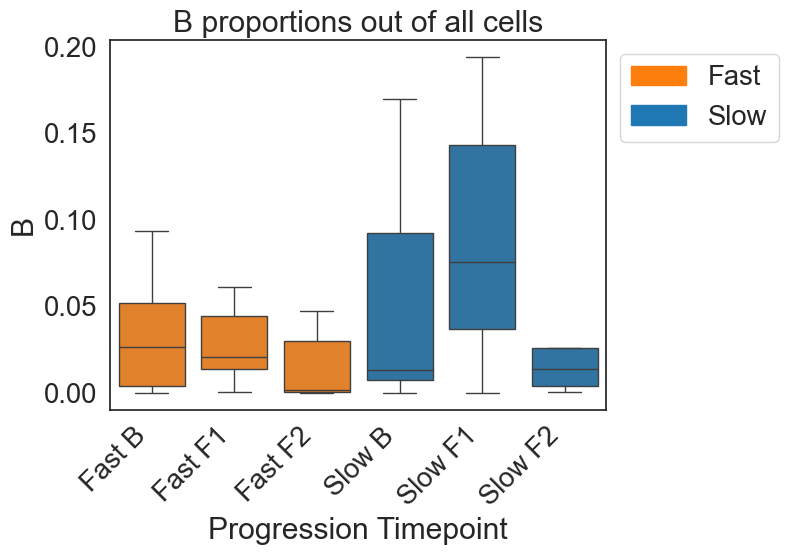

In [48]:
import matplotlib.patches as mpatches
sns.set(font_scale=1.8)
sns.set_style('white')
sns.boxplot(data=all_props, y="B", x="Progression Timepoint",
               hue="Progression Timepoint",
              palette={'Slow B':'tab:blue','Slow F1':'tab:blue','Slow F2':'tab:blue',
                       'Fast B':'tab:orange','Fast F1':'tab:orange','Fast F2':'tab:orange'},
               order=['Fast B','Fast F1','Fast F2',
                            'Slow B','Slow F1','Slow F2'],showfliers=False
              )
orange_patch = mpatches.Patch(color='tab:orange',label='Fast')
blue_patch = mpatches.Patch(color='tab:blue', label='Slow')
plt.title('B proportions out of all cells')
plt.legend(handles=[orange_patch,blue_patch],bbox_to_anchor=(1,1))
plt.xticks(rotation=45,ha='right')

In [49]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['Plasma'],
         all_props[all_props['Progression Timepoint'] == 'Slow B']['Plasma'])

RanksumsResult(statistic=1.3377378232150465, pvalue=0.1809819166727319)

In [50]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['Plasma'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['Plasma'])

RanksumsResult(statistic=-0.5061710682435311, pvalue=0.6127365634531112)

In [51]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F2']['Plasma'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['Plasma'])

RanksumsResult(statistic=-1.0819287385573255, pvalue=0.2792841938529813)

In [52]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow B']['Plasma'],
         all_props[all_props['Progression Timepoint'] == 'Slow F1']['Plasma'])

RanksumsResult(statistic=-0.4429403980178329, pvalue=0.6578088460507269)

In [53]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Slow F1']['Plasma'],
         all_props[all_props['Progression Timepoint'] == 'Slow F2']['Plasma'])

RanksumsResult(statistic=1.518226232564234, pvalue=0.12895737659138537)

In [54]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast B']['Plasma'],
         all_props[all_props['Progression Timepoint'] == 'Fast F1']['Plasma'])

RanksumsResult(statistic=1.3065591353603359, pvalue=0.1913624828830619)

In [55]:
from scipy.stats import ranksums
ranksums(all_props[all_props['Progression Timepoint'] == 'Fast F1']['Plasma'],
         all_props[all_props['Progression Timepoint'] == 'Fast F2']['Plasma'])

RanksumsResult(statistic=2.2057470084576485, pvalue=0.02740171849986683)

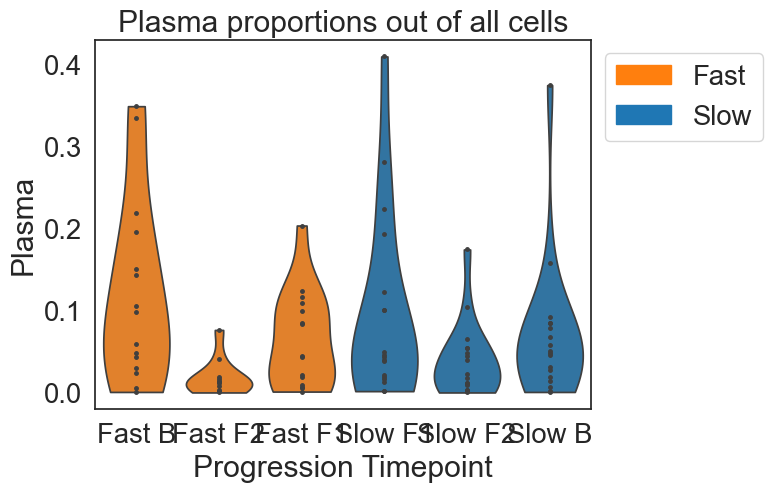

In [56]:
import matplotlib.patches as mpatches
sns.violinplot(data=all_props, y="Plasma", x="Progression Timepoint",
               hue="Progression Timepoint",inner="point",
              palette={'Slow B':'tab:blue','Slow F1':'tab:blue','Slow F2':'tab:blue',
                       'Fast B':'tab:orange','Fast F1':'tab:orange','Fast F2':'tab:orange'},cut=0
              )
orange_patch = mpatches.Patch(color='tab:orange',label='Fast')
blue_patch = mpatches.Patch(color='tab:blue', label='Slow')
plt.title('Plasma proportions out of all cells')
plt.legend(handles=[orange_patch,blue_patch],bbox_to_anchor=(1,1))
plt.savefig('/home/jupyter/data/ge_korea/results/apc_proportions/plasma_div_all.pdf',
           bbox_inches='tight')